## 1. Install and Configure TensorFlow/Keras

Google Colab normally includes TensorFlow. The following cell installs/updates the required packages and then verifies the installation.

In [ ]:
!pip -q install -U tensorflow keras matplotlib seaborn scikit-learn

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 961.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 27.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.21.0 which is incompatible.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.1

## 2. Load the Sample Dataset

MNIST contains grayscale images of handwritten digits from 0 to 9. Each image is 28 × 28 pixels.

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Original training data shape:", x_train.shape)
print("Original training labels shape:", y_train.shape)
print("Original test data shape:", x_test.shape)
print("Original test labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training data shape: (60000, 28, 28)
Original training labels shape: (60000,)
Original test data shape: (10000, 28, 28)
Original test labels shape: (10000,)


## 3. Inspect the Dataset

Check the pixel range, labels, and a few sample images before preprocessing.

Pixel value range: 0 to 255
Unique labels: [0 1 2 3 4 5 6 7 8 9]


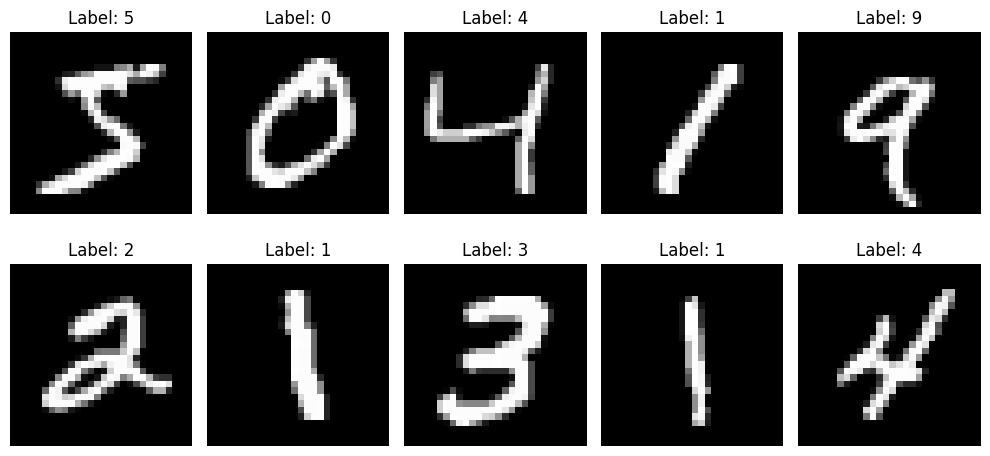

In [ ]:
print("Pixel value range:", x_train.min(), "to", x_train.max())
print("Unique labels:", np.unique(y_train))

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

The images are converted to `float32` and normalized from the original 0–255 pixel range to 0–1. The labels remain integer class values.

In [ ]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

print("After normalization:")
print("Training pixel range:", x_train.min(), "to", x_train.max())
print("Test pixel range:", x_test.min(), "to", x_test.max())

After normalization:
Training pixel range: 0.0 to 1.0
Test pixel range: 0.0 to 1.0


## 5. Train-Test Split

MNIST already provides separate training and test sets. For this assignment, the provided training set is further divided into **80% training** and **20% validation**, while the original test set is kept untouched for final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training set:", x_train_split.shape, y_train_split.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

Training set: (48000, 28, 28) (48000,)
Validation set: (12000, 28, 28) (12000,)
Test set: (10000, 28, 28) (10000,)


## 6. Visualize Normalized Images

Display several normalized images to verify that preprocessing did not destroy the image information.

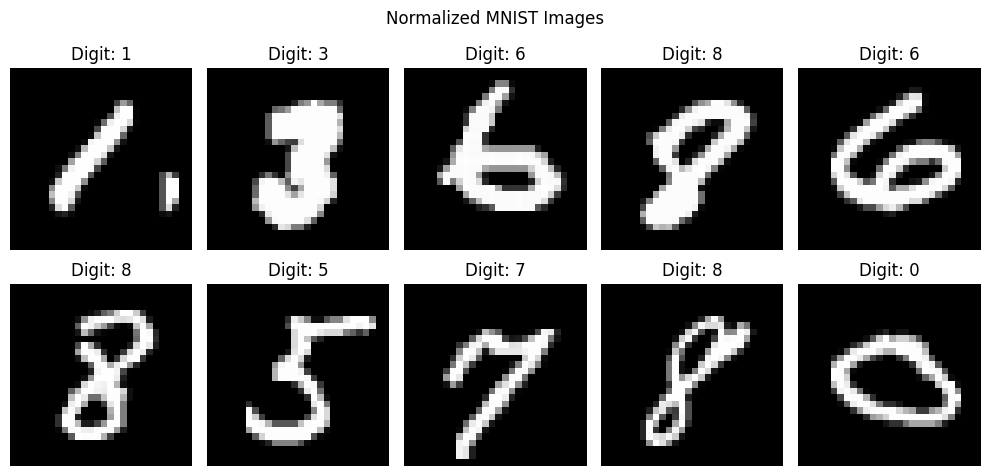

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_split[i], cmap="gray", vmin=0, vmax=1)
    plt.title(f"Digit: {y_train_split[i]}")
    plt.axis("off")
plt.suptitle("Normalized MNIST Images")
plt.tight_layout()
plt.show()

## 7. Visualize Class Distribution

A class distribution plot helps check whether the digit classes are reasonably balanced.

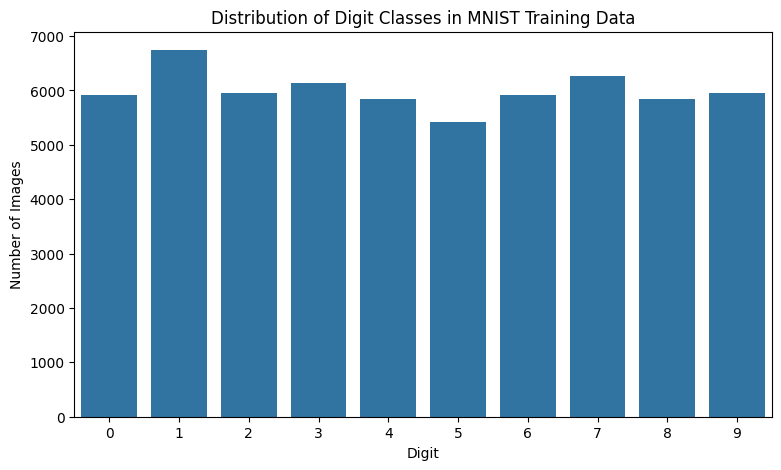

Class counts:
Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(9, 5))
sns.barplot(x=unique, y=counts)
plt.title("Distribution of Digit Classes in MNIST Training Data")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.show()

print("Class counts:")
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count}")

## 8. Pixel Intensity Visualization

The histogram shows the distribution of normalized pixel values.

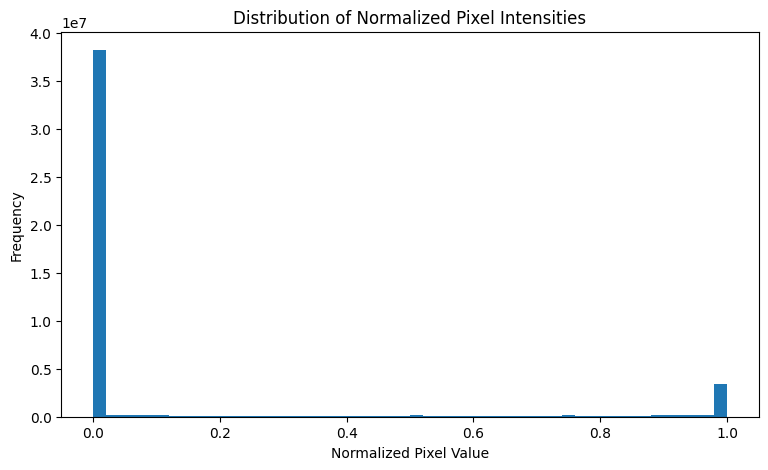

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(x_train.flatten(), bins=50)
plt.title("Distribution of Normalized Pixel Intensities")
plt.xlabel("Normalized Pixel Value")
plt.ylabel("Frequency")
plt.show()

## 9. Display One Image as a Pixel Matrix

This demonstrates how a normalized image is represented numerically.

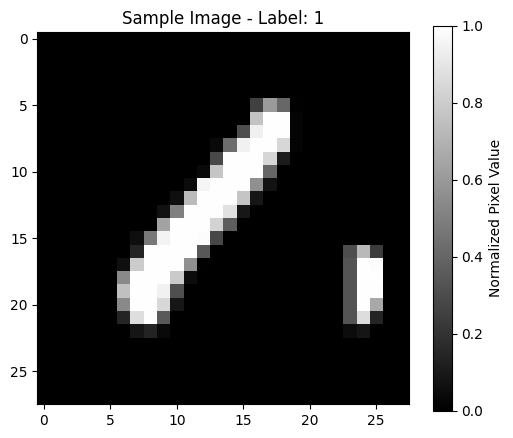

Image shape: (28, 28)
First 5 rows of normalized pixel values:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]]


In [ ]:
sample_index = 0

plt.figure(figsize=(6, 5))
plt.imshow(x_train_split[sample_index], cmap="gray", vmin=0, vmax=1)
plt.colorbar(label="Normalized Pixel Value")
plt.title(f"Sample Image - Label: {y_train_split[sample_index]}")
plt.show()

print("Image shape:", x_train_split[sample_index].shape)
print("First 5 rows of normalized pixel values:")
print(x_train_split[sample_index][:5])

## 10. Optional Keras Model Configuration

To verify that the preprocessed data is compatible with Keras, create a simple neural network and train it briefly. This is not required for preprocessing, but demonstrates that the prepared dataset can be directly used in a TensorFlow/Keras workflow.

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train_split,
    y_train_split,
    validation_data=(x_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)

Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8764 - loss: 0.4315 - val_accuracy: 0.9389 - val_loss: 0.2196
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9411 - loss: 0.2063 - val_accuracy: 0.9542 - val_loss: 0.1631
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9552 - loss: 0.1585 - val_accuracy: 0.9598 - val_loss: 0.1355


## 11. Visualize Training and Validation Accuracy

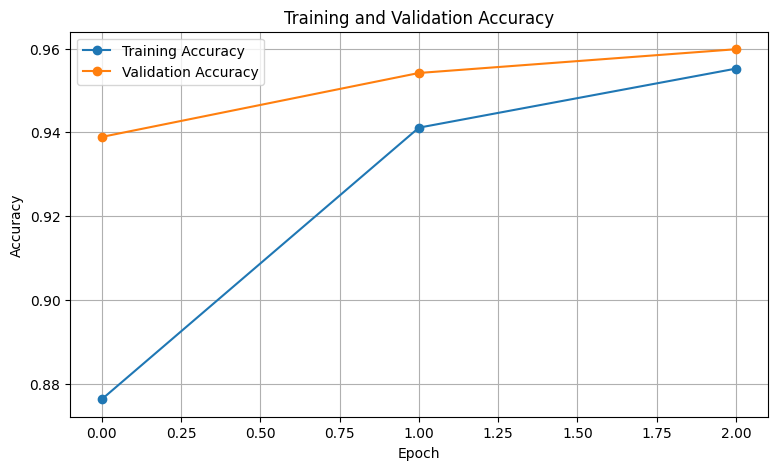

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 12. Final Test Evaluation

Evaluate the trained Keras model on the untouched test set.

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.1238
Test Accuracy: 0.9639
Test Accuracy: 96.39%
